<a href="https://colab.research.google.com/github/shounik1904-crypto/Interelite-Minor-Project/blob/MAIN-2/UBER_FARE_PREDICTOR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Original Dataset Shape: (200000, 9)
Shape After Cleaning: (199269, 9)

MODEL PERFORMANCE
MAE : 2.44
MSE : 29.42
RMSE: 5.42
R2 Score: 0.6944

Sample Predictions:
   Actual Fare  Predicted Fare
0          5.3        7.160126
1          6.5        5.141781
2         12.5       18.665565
3          6.9       10.103094
4         15.7       21.138587
5          6.5        8.391123
6          4.5        6.711910
7         14.1       14.549543
8          8.5        8.644832
9         11.0       10.033600


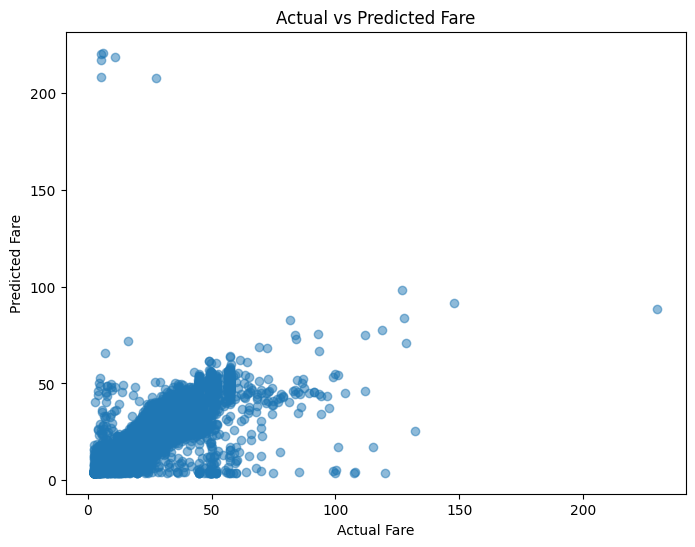


UBER / OLA FARE ESTIMATOR


In [ ]:
# ==========================================
# UBER / OLA FARE ESTIMATOR
# LINEAR REGRESSION PROJECT
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ==========================================
# LOAD DATASET
# ==========================================

df = pd.read_csv('/content/uber.csv')

print("Original Dataset Shape:", df.shape)

# ==========================================
# DATA CLEANING
# ==========================================

df = df.dropna()

df = df[df['fare_amount'] > 0]

df = df[df['passenger_count'] > 0]

print("Shape After Cleaning:", df.shape)

# ==========================================
# HAVERSINE DISTANCE FUNCTION
# ==========================================

def haversine(lat1, lon1, lat2, lon2):

    R = 6371

    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (np.sin(dlat / 2) ** 2 +
         np.cos(lat1) *
         np.cos(lat2) *
         np.sin(dlon / 2) ** 2)

    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

    return R * c

# ==========================================
# CREATE DISTANCE FEATURE
# ==========================================

df['distance_km'] = haversine(
    df['pickup_latitude'],
    df['pickup_longitude'],
    df['dropoff_latitude'],
    df['dropoff_longitude']
)

# Remove unrealistic distances

df = df[(df['distance_km'] > 0) & (df['distance_km'] < 100)]

# ==========================================
# CREATE TIME FEATURE
# ==========================================

# Approximate travel time based on distance

np.random.seed(42)

df['time_min'] = (
    df['distance_km'] *
    np.random.uniform(2.0, 5.0, len(df))
)

# ==========================================
# CREATE TRAFFIC FEATURE
# ==========================================

# 1 = Low
# 2 = Medium
# 3 = High

df['traffic_level'] = np.random.randint(
    1,
    4,
    len(df)
)

# ==========================================
# FEATURES & TARGET
# ==========================================

X = df[
    [
        'distance_km',
        'time_min',
        'traffic_level'
    ]
]

y = df['fare_amount']

# ==========================================
# TRAIN TEST SPLIT
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# ==========================================
# TRAIN MODEL
# ==========================================

model = LinearRegression()

model.fit(X_train, y_train)

# ==========================================
# PREDICTION
# ==========================================

y_pred = model.predict(X_test)

# ==========================================
# MODEL EVALUATION
# ==========================================

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("\n==============================")
print("MODEL PERFORMANCE")
print("==============================")

print("MAE :", round(mae, 2))
print("MSE :", round(mse, 2))
print("RMSE:", round(rmse, 2))
print("R2 Score:", round(r2, 4))

# ==========================================
# ACTUAL VS PREDICTED
# ==========================================

comparison = pd.DataFrame({
    'Actual Fare': y_test.values,
    'Predicted Fare': y_pred
})

print("\nSample Predictions:")
print(comparison.head(10))

# ==========================================
# VISUALIZATION
# ==========================================

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.5)

plt.xlabel("Actual Fare")
plt.ylabel("Predicted Fare")
plt.title("Actual vs Predicted Fare")

plt.show()

# ==========================================
# USER INPUT SECTION
# ==========================================

print("\n==============================")
print("UBER / OLA FARE ESTIMATOR")
print("==============================")

distance_km = float(input("Enter Distance (km): "))

time_min = float(input("Enter Time (minutes): "))

traffic_level = int(
    input(
        "Enter Traffic Level (1=Low, 2=Medium, 3=High): "
    )
)

estimated_fare = model.predict(
    [[distance_km, time_min, traffic_level]]
)

print(
    "\nEstimated Fare = ₹",
    round(estimated_fare[0], 2)
)